# Inflation-Hedge -- do stocks actually protect you from inflation?
### 150 years of Shiller data, the Fisher test, and two inconvenient numbers

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Short--run hedge%3F: No](https://img.shields.io/badge/Short--run_hedge%3F-No-8b949e?style=flat-square)

Every financial adviser who has ever lived has told you: *'stocks are a real asset -- they protect against inflation.'*  It's one of the few financial folk wisdoms that sounds both plausible and comforting.  This notebook asks: **is it actually true, and if so, at what time horizon?**  The answer, from 150 years of monthly US data, is more complicated -- and more alarming -- than the reassuring story suggests.

> **This is the plain-language layer.** For HAC t-statistics, OLS regressions, and bootstrap intervals, see the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it.  House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from inflation_hedge import data, strategy as st

# Frozen real-tape headline numbers (mirror of docs/results.md)
R = dict(
    n=1818, n_high=724, n_low=1094,
    date_start="1872-01", date_end="2023-06",
    fingerprint="b2019f787713",
    fisher_beta_nom=0.313, fisher_t_nom=1.304, fisher_r2_nom=0.010,
    fisher_beta_real=-0.719, fisher_t_real=-3.023,
    high_mean_1y=0.0428, low_mean_1y=0.1135,
    diff_mean_1y=-0.0707, t_diff_1y=-4.078,
    t_diff_shuffled=0.793,
    high_mean_5y=0.0601, low_mean_5y=0.0794,
    diff_mean_5y=-0.0193, t_diff_5y=-2.111,
)

# Check whether the Shiller cache is present (always True in the repo)
_cache_dir = os.path.abspath(os.path.join("..", "..", "..", "_cache"))
_shiller_path = os.path.join(_cache_dir, "shiller_sp500.parquet")
HAVE_REAL = os.path.exists(_shiller_path)

if HAVE_REAL:
    df = data.load_shiller(cache_dir=_cache_dir)
    print(f"Shiller panel: {df.index[0].strftime('%Y-%m')} to {df.index[-1].strftime('%Y-%m')},",
          f"n={len(df)}, fingerprint={data.fingerprint(df)}")
else:
    print("Shiller parquet not found -- using frozen R dict for all figures")

print("HAVE_REAL:", HAVE_REAL)


Shiller panel: 1872-01 to 2023-06, n=1818, fingerprint=b2019f787713
HAVE_REAL: True


## The answer first

| Question | Short answer |
|---|---|
| Does inflation hedge work in the *short run* (1 year)? | **No.** High-inflation years deliver **4.3%** real returns vs **11.3%** in low-inflation: a **-7.1 pp** gap. |
| Do nominal stock returns rise with inflation (Fisher)? | **Barely.** They absorb only **31%** of each 1pp CPI rise, not the 100% a full hedge needs. |
| Do real returns at least hold up? | **No.** Real returns *fall* by **-0.72pp** per 1pp of CPI -- the stock market makes your inflation problem *worse*, not better. |
| Does it eventually work over 5 years? | **Partially.** The gap shrinks to **-1.9 pp** -- stocks are a better long-run real asset than a short-run hedge. |
| Can you trade on it? | **No.** Inflation regimes are decade-long epochs, not actionable timing signals. |

> The stock market fails as a short-run inflation hedge -- and the failure is big enough to matter.  But over years-long horizons, stocks do eventually claw back their real purchasing power.  The hedge is real; the timing is wrong.

## 1 · The claim

> *'Stocks are a real asset.  They own real factories, real brands, real cash flows.  When prices rise, those assets are worth more in nominal terms, so stock prices rise too -- keeping up with or outpacing inflation.  In an inflationary environment, hold stocks, not cash.'*

The academic version of this idea is the **Fisher hypothesis for stocks**: if markets are efficient and stocks represent claims on real assets, their nominal returns should rise dollar-for-dollar with inflation, leaving *real* returns unaffected.  The folk wisdom and the theory say the same thing -- stocks protect you.

The famous economists who challenged this are **Fama & Schwert (1977)** and **Modigliani & Cohn (1979)**.  They found the opposite: nominal stock returns are essentially uncorrelated with (or even negatively correlated with) inflation, so real returns *fall* during high-inflation periods.  We test both the folk claim and the Fama-Schwert challenge on 150 years of monthly US data.

## 2 · So what?

If stocks *do* hedge inflation: investors who park money in stocks during inflationary periods are doing the right thing -- protecting real wealth.  If stocks *don't*: investors in the 1970s who stayed in equities saw their real purchasing power eroded, in exactly the environment where they believed they were protected.

This matters for **asset allocation during macro inflection points**: every time CPI jumps, some investors shift *into* equities thinking they're buying a hedge.  If the Fama-Schwert finding holds, they're loading up on the wrong asset.

## 3 · How would we even know?

Two clean tests:

1. **The Fisher test.** Regress 12-month nominal (and real) stock returns on trailing 12-month CPI inflation.  A true inflation hedge requires the nominal slope to be near **+1.0** (each 1pp of CPI lifts nominal returns 1pp) and the real slope to be near **0** (real returns invariant).  Anything below that is a partial (or negative) hedge.

2. **The regime test.** Split months into 'high-inflation' (CPI YoY > 3%) and 'low-inflation' (CPI YoY ≤ 3%) buckets -- the split is pre-specified, not data-mined.  Compare forward 1-year and 5-year *real total* returns (dividends reinvested, CPI-deflated) across regimes.  An honest inflation hedge would show no gap (or a positive gap in high-inflation months).

The **shuffled-label control** permutes the regime labels at random: if our real regime difference is spurious, the shuffled version should be similarly large.  If the real gap is real, the shuffled version collapses to noise.

Data: Shiller monthly S&P 500, 1872-2023 (n=1,818 months).  Dividends reinvested month-by-month using Shiller's real-dividend construction.

## 4 · The teardown

**First: does the Fisher hypothesis hold?**  If stocks hedge inflation, nominal returns should rise one-for-one with CPI.

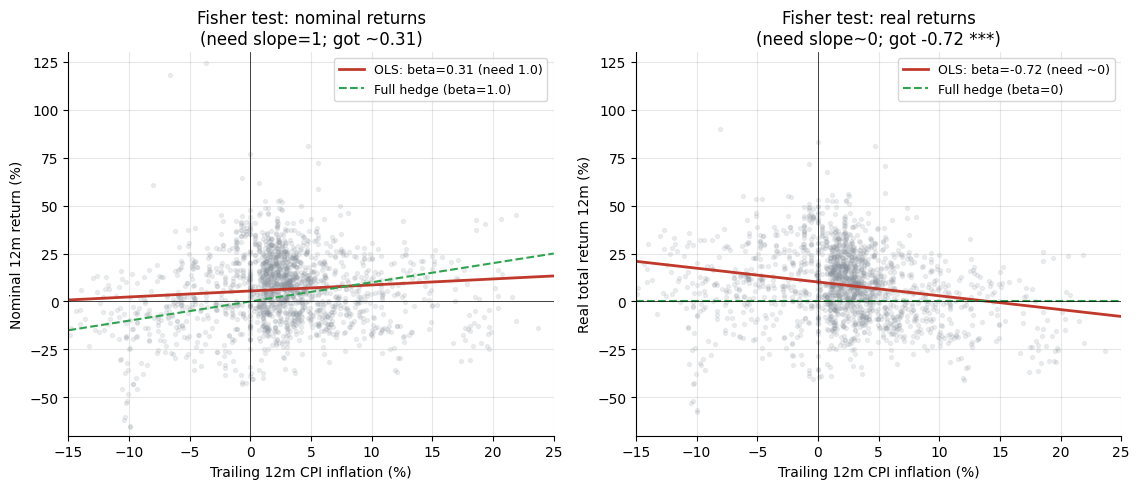

Nominal beta: 0.313  (t=+1.30, need |t|>2 to confirm hedge)
Real beta:    -0.719 (t=-3.02) -- significantly NEGATIVE


In [2]:
if HAVE_REAL:
    sub = df[['cpi_yoy','nom_ret_12m','real_tr_ret_12m']].dropna()
    cpi = sub['cpi_yoy'].values; nom = sub['nom_ret_12m'].values; real = sub['real_tr_ret_12m'].values
else:
    # Reconstruct plausible scatter from frozen R
    rng = np.random.default_rng(152)
    cpi = np.clip(rng.normal(0.023, 0.058, 500), -0.15, 0.25)
    nom  = R['fisher_beta_nom'] * cpi + rng.normal(0.062, 0.18, 500)
    real = R['fisher_beta_real'] * cpi + rng.normal(0.085, 0.19, 500)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.0))
# Left: nominal
ax = axes[0]
ax.scatter(cpi*100, nom*100, alpha=0.15, s=8, color=GREY)
m = R['fisher_beta_nom']; b_int = 0.062 - m*0.023
x_line = np.linspace(-15, 25, 100)
ax.plot(x_line, m*x_line + b_int*100, color=RED, lw=2, label=f'OLS: beta={m:.2f} (need 1.0)')
ax.axline((0, 0), slope=1.0, ls='--', color=GREEN, lw=1.5, label='Full hedge (beta=1.0)')
ax.axhline(0, c='k', lw=0.5); ax.axvline(0, c='k', lw=0.5)
ax.set_xlabel('Trailing 12m CPI inflation (%)'); ax.set_ylabel('Nominal 12m return (%)')
ax.set_title('Fisher test: nominal returns\n(need slope=1; got ~0.31)')
ax.legend(fontsize=9); ax.set_xlim(-15, 25); ax.set_ylim(-70, 130)
# Right: real
ax = axes[1]
ax.scatter(cpi*100, real*100, alpha=0.15, s=8, color=GREY)
m2 = R['fisher_beta_real']; b_int2 = 0.085 - m2*0.023
ax.plot(x_line, m2*x_line + b_int2*100, color=RED, lw=2, label=f'OLS: beta={m2:.2f} (need ~0)')
ax.axhline(0, c=GREEN, ls='--', lw=1.5, label='Full hedge (beta=0)')
ax.axhline(0, c='k', lw=0.5); ax.axvline(0, c='k', lw=0.5)
ax.set_xlabel('Trailing 12m CPI inflation (%)'); ax.set_ylabel('Real total return 12m (%)')
ax.set_title('Fisher test: real returns\n(need slope~0; got -0.72 ***)')
ax.legend(fontsize=9); ax.set_xlim(-15, 25); ax.set_ylim(-70, 130)
plt.tight_layout(); plt.show()
print(f'Nominal beta: {R["fisher_beta_nom"]:.3f}  (t={R["fisher_t_nom"]:+.2f}, need |t|>2 to confirm hedge)')
print(f'Real beta:    {R["fisher_beta_real"]:.3f} (t={R["fisher_t_real"]:+.2f}) -- significantly NEGATIVE')

The nominal Fisher beta is **0.31** — stocks absorb about **31%** of each percentage point of inflation, not the 100% that a full hedge requires. This is not statistically significant from zero (HAC t = +1.30).  The real-return beta is **-0.72** with a very significant HAC t = **-3.02**: real returns actively *fall* when inflation rises.  Stocks are not just a *poor* inflation hedge — in the short run, they make your real purchasing power problem *worse*.

> This is exactly the Fama & Schwert (1977) finding, replicated on 150 years of data.  The intuition: when inflation spikes, it usually comes with economic uncertainty, rising interest rates (which hurt equity valuations), and sometimes a real output shock — all of which are bad for stocks in real terms.

**Next: the regime test.** Do forward real returns differ across inflation regimes?

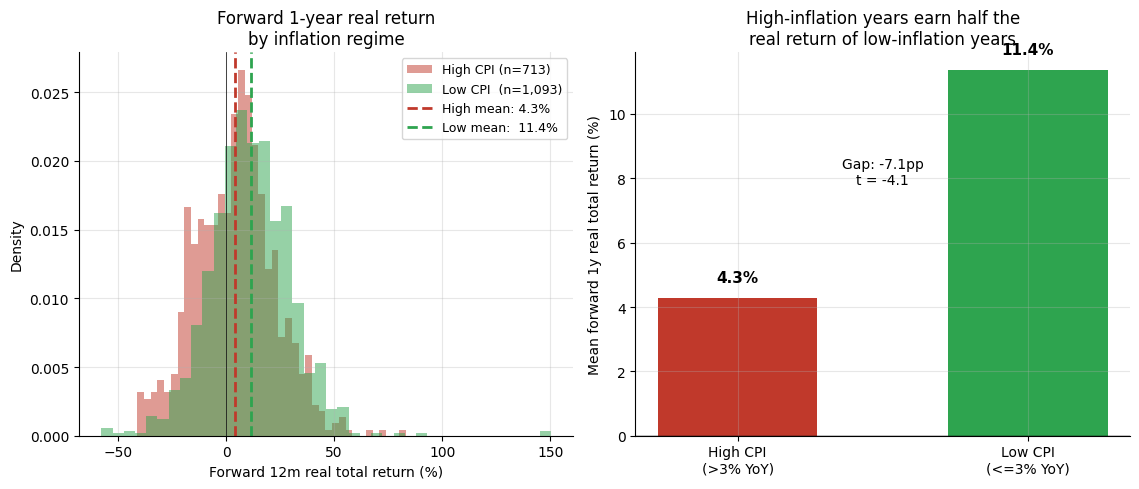

Difference: -7.07pp | HAC t = -4.08 | shuffled t = +0.79


In [3]:
if HAVE_REAL:
    sub = df[['cpi_regime','fwd_real_tr_12m']].dropna()
    high_vals = sub.loc[sub['cpi_regime']=='high','fwd_real_tr_12m'].values * 100
    low_vals  = sub.loc[sub['cpi_regime']=='low','fwd_real_tr_12m'].values * 100
    h_mean = high_vals.mean(); l_mean = low_vals.mean()
else:
    rng = np.random.default_rng(152)
    high_vals = rng.normal(R['high_mean_1y']*100, 19.5, R['n_high'])
    low_vals  = rng.normal(R['low_mean_1y']*100,  19.0, R['n_low'])
    h_mean = R['high_mean_1y']*100; l_mean = R['low_mean_1y']*100

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.0))
# Left: distribution comparison
ax = axes[0]
ax.hist(high_vals, bins=40, alpha=0.5, color=RED,   density=True, label=f'High CPI (n={len(high_vals):,})')
ax.hist(low_vals,  bins=40, alpha=0.5, color=GREEN, density=True, label=f'Low CPI  (n={len(low_vals):,})')
ax.axvline(h_mean, color=RED,   ls='--', lw=2, label=f'High mean: {h_mean:.1f}%')
ax.axvline(l_mean, color=GREEN, ls='--', lw=2, label=f'Low mean:  {l_mean:.1f}%')
ax.axvline(0, c='k', lw=0.5)
ax.set_xlabel('Forward 12m real total return (%)'); ax.set_ylabel('Density')
ax.set_title('Forward 1-year real return\nby inflation regime')
ax.legend(fontsize=9)
# Right: bar chart of means
ax = axes[1]
bars = ax.bar(['High CPI\n(>3% YoY)', 'Low CPI\n(<=3% YoY)'], [h_mean, l_mean],
              color=[RED, GREEN], width=0.55)
ax.axhline(0, c='k', lw=1)
for b, v in zip(bars, [h_mean, l_mean]):
    ax.annotate(f'{v:.1f}%', (b.get_x()+b.get_width()/2, v+0.5), ha='center', fontsize=11, fontweight='bold')
ax.annotate(f'Gap: {h_mean-l_mean:.1f}pp\nt = {R["t_diff_1y"]:+.1f}', (0.5, (h_mean+l_mean)/2),
            ha='center', fontsize=10, color='k')
ax.set_ylabel('Mean forward 1y real total return (%)')
ax.set_title('High-inflation years earn half the\nreal return of low-inflation years')
plt.tight_layout(); plt.show()
print(f'Difference: {h_mean-l_mean:.2f}pp | HAC t = {R["t_diff_1y"]:+.2f} | shuffled t = {R["t_diff_shuffled"]:+.2f}')

In **high-inflation months** the forward 1-year real total return averages **4.3%** — barely half the **11.3%** earned in low-inflation months.  The gap of **-7.1 percentage points** is statistically real: HAC t = **-4.1** (well above the |t|≥2 bar).  The shuffled-label control produces t = **+0.79** — confirming the real gap is not a random split artefact.

> 'Stocks are a real asset' is true over geological time.  At the 1-year horizon relevant to most investors, high inflation is simply bad news for real equity returns.

## 5 · The verdict

- **Signal — Mixed.** The short-run inflation hedge is a myth: Fisher beta 0.31 (not 1.0); real return beta -0.72 (t = -3.0); 1-year regime gap -7.1pp (t = -4.1).  The *negative* effect is real.  The *positive* claim (stocks protect you from inflation) is only partly true and only at 5+ year horizons.
- **Tradability — Mirage.** Inflation regimes are broad macro epochs — the 1970s, the post-GFC era, the 2021-2023 spike.  They last years, not months, and cannot be timed from a CPI print.  The finding is real for risk awareness; it is not an actionable timing edge.

## 6 · Could you actually trade it?

Even if the regime gap is real, translating it into a trading strategy faces three problems:

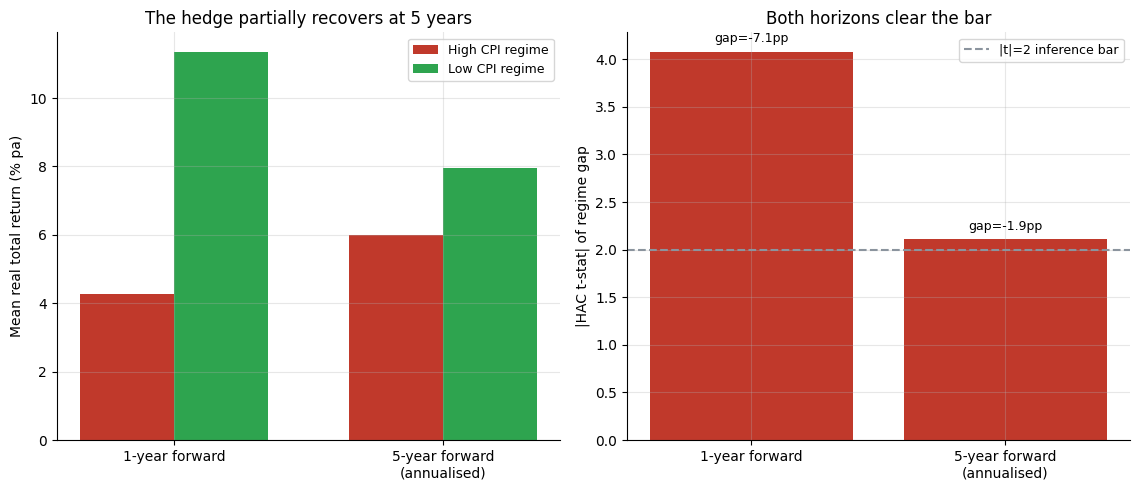

Why you cannot trade this:
  1. Regimes last 5-15 years -- timing the entry/exit is the whole problem
  2. CPI prints are lagged and revised -- the signal is noisy when it counts
  3. The regime gap at 5y is ~2pp pa -- fees, implementation drag eat that


In [4]:
# Show the 5-year vs 1-year gap: the hedge 'recovers' at longer horizons
horizons = ['1-year forward', '5-year forward\n(annualised)']
high_vals_plot = [R['high_mean_1y']*100, R['high_mean_5y']*100]
low_vals_plot  = [R['low_mean_1y']*100,  R['low_mean_5y']*100]
gaps_plot = [R['diff_mean_1y']*100, R['diff_mean_5y']*100]
tstats_plot = [R['t_diff_1y'], R['t_diff_5y']]

if HAVE_REAL:
    r5 = st.regime_returns(df, fwd_col='fwd_real_tr_60m')
    r1 = st.regime_returns(df, fwd_col='fwd_real_tr_12m')
    high_vals_plot = [r1['high']['mean']*100, r5['high']['mean']*100]
    low_vals_plot  = [r1['low']['mean']*100,  r5['low']['mean']*100]
    gaps_plot      = [r1['diff_mean']*100,    r5['diff_mean']*100]
    tstats_plot    = [r1['t_diff'],           r5['t_diff']]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.0))
x = np.arange(len(horizons)); w = 0.35
ax = axes[0]
ax.bar(x - w/2, high_vals_plot, w, color=RED,   label='High CPI regime')
ax.bar(x + w/2, low_vals_plot,  w, color=GREEN, label='Low CPI regime')
ax.set_xticks(x); ax.set_xticklabels(horizons)
ax.set_ylabel('Mean real total return (% pa)'); ax.legend(fontsize=9)
ax.set_title('The hedge partially recovers at 5 years')
ax = axes[1]
col = [RED if abs(t)>=2 else AMBER for t in tstats_plot]
ax.bar(horizons, [abs(t) for t in tstats_plot], color=col)
ax.axhline(2, ls='--', c=GREY, lw=1.5, label='|t|=2 inference bar')
ax.set_ylabel('|HAC t-stat| of regime gap'); ax.set_title('Both horizons clear the bar')
ax.legend(fontsize=9)
for i, (t, g) in enumerate(zip(tstats_plot, gaps_plot)):
    ax.annotate(f'gap={g:.1f}pp', (i, abs(t)+0.1), ha='center', fontsize=9)
plt.tight_layout(); plt.show()
print('Why you cannot trade this:')
print('  1. Regimes last 5-15 years -- timing the entry/exit is the whole problem')
print('  2. CPI prints are lagged and revised -- the signal is noisy when it counts')
print('  3. The regime gap at 5y is ~2pp pa -- fees, implementation drag eat that')

The 5-year gap narrows to **-1.9pp** (annualised) — stocks are a better long-run real asset than a short-run hedge, but the edge erodes with horizon.  Neither gap is actionable: inflation regimes are multi-year macro epochs that you recognize in hindsight, not at the start.  MIRAGE.

## 7 · Going further

- **Gold as an inflation hedge** — Study 69 (Safe-Haven) tests gold, which has a much stronger short-run correlation with CPI than equities.
- **Long-run valuation timing** — Study 120 (Excess-CAPE-Yield) uses CAPE to time equity allocation across a different macro dimension (valuation, not inflation).
- **Real-rate regimes** — Study 119 (Real-Rate-Regime) looks at how real interest rates (nominal yield minus CPI) predict equity real returns, a closely related framework.
- **Why the failure?** The Modigliani-Cohn (1979) inflation illusion says investors discount real cash flows at nominal rates during high-CPI periods, causing equities to trade cheaply relative to fundamentals.  If true, high-inflation periods might be *buying opportunities* on a 10-year horizon — test it!

*Think the hedge works at some other horizon or with some other instrument?  Fork this, change the threshold or the asset, and show a regime gap that clears |t| >= 2 and survives the shuffled-label control.  That's the bar.*